In [1]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
import cv2
import pdb
from PIL import Image
import matplotlib.pyplot as plt 

In [2]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [6]:
len(train_loss)

100

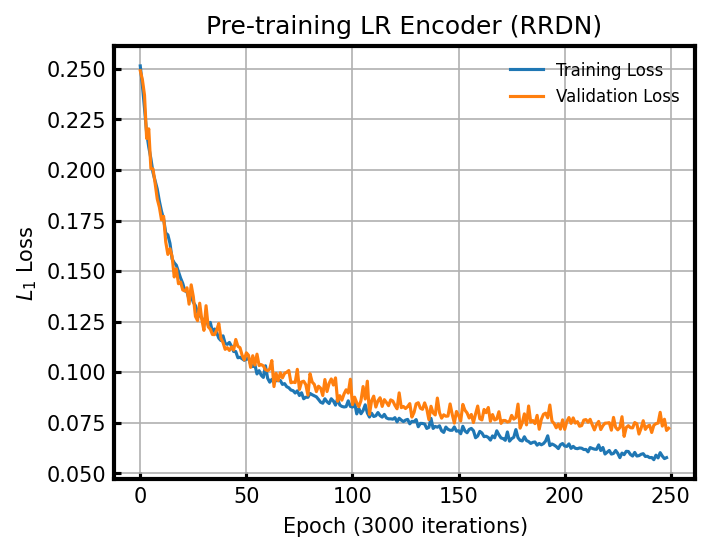

In [4]:
test_loss = np.loadtxt('/home/oogoke/DiffusionSR/runs/clean/direct/encoder/2022_12_04_11_32_01/standardize/test_loss.txt')
train_loss = np.loadtxt('/home/oogoke/DiffusionSR/runs/clean/direct/encoder/2022_12_04_11_32_01/standardize/train_loss.txt')

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[1:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()
plt.title('Pre-training LR Encoder (RRDN)')
plt.grid(which = 'major')
frame_tick()

In [5]:
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset

class MyDataset(Dataset):
    # def __init__(self, image_paths, target_paths):
    def __init__(self, hr_paths, lr_paths, image_paths, mean = None, std = None, mean_lrs = None, std_lrs = None):
        self.image_paths = image_paths
        self.hr_paths = hr_paths
        self.lr_paths = lr_paths

        self.mean = mean
        self.std = std

        self.mean_lrs = mean_lrs
        self.std_lrs = std_lrs
        self.std[self.std == 0] = 1
        self.std_lrs[self.std_lrs == 0] = 1

        # self.target_paths = target_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        ip = np.load(self.image_paths[index], allow_pickle = True)
        hr = np.load(self.hr_paths[index], allow_pickle = True)
        lr = np.load(self.lr_paths[index], allow_pickle = True)

        ip[ip > 7000] = 7000
        hr[hr > 7000] = 7000

        lr[lr > 7000] = 7000
        # op = np.load(self.target_paths[index], allow_pickle = True)
        x = (ip  - self.mean)/self.std
        hr = (hr  - self.mean)/self.std
        lr = (lr  - self.mean_lrs)/self.std_lrs
        # x = torch.Tensor(((ip-293)/(7000-293)) - 1) #torch.Tensor((ip  - self.mean)/self.std)
        # y = torch.Tensor(op)
        # return x, y
        return x, hr, lr


image_size = 80
channels = 1
batch_size = 4


OSError: /home/oogoke/SRdataset/r2_encoder_results_normalized_8_blocks_test_all/train_idx not found.

In [8]:
from torch.utils.data import DataLoader
from datasets.dataset import TemperatureXZDataset
results_dir = '/home/oogoke/runs/clean/lanczos/encoder/2022_11_28_01_23_44'
os.makedirs(results_dir, exist_ok = True)
# mean = np.load('./mean_dataset.npy')
# std = np.load('./std_dataset.npy')
# breakpoint()
# breakpoint()
batch_size = 32
train_dataset = TemperatureXZDataset(method = 'lanczos', split = 'train')
test_dataset = TemperatureXZDataset(method ='lanczos', split = 'test')
dev_dataset = TemperatureXZDataset(method = 'lanczos', split = 'dev')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

std_lr =  train_dataset.std_lr
mean_lr = train_dataset.mean_lr  
std_resid =  train_dataset.std_resid
mean_resid =  train_dataset.mean_resid
mean = train_dataset.mean_hr 
std = train_dataset.std_hr

len data: 3044
len data: 609
len data: 406


In [9]:
# np.load(lr_paths[0]).shape

# def train_epoch(model, data_loader, criterion, optimizer, epoch = 0, image_dir = ''):
device = 'cuda'
criterion = torch.nn.L1Loss()
data_loader = dataloader
learning_rate = 1e-4

from models.lr_encoder_model import rrdbnet_encoder

device = 'cuda'
lr_enc = rrdbnet_encoder(num_blocks = 8)

lr_enc.to(device)
learning_rate = 5e-5
lr_encoptimizer = torch.optim.Adam(lr_enc.parameters(), lr=learning_rate,weight_decay = 0)
lrenc_fname = os.path.join(results_dir, 'model_saved.pth')
lrenc_checkpoint = torch.load(lrenc_fname)
lr_enc.load_state_dict(lrenc_checkpoint['model_state_dict'])
lr_encoptimizer.load_state_dict(lrenc_checkpoint['optimizer_state_dict'])
lr_enc.eval()
import torch.nn.functional as F



def forwardpass(lr_enc, sample):
    out1 = lr_enc.conv1(sample)
    out = lr_enc.trunk(out1)
    out2 = lr_enc.conv2(out)
    out = torch.add(out1, out2)

    if lr_enc.upscale_factor == 2:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
    if lr_enc.upscale_factor == 4:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling2(F.interpolate(out, scale_factor=2, mode="nearest"))
    if lr_enc.upscale_factor == 8:
        out = lr_enc.upsampling1(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling2(F.interpolate(out, scale_factor=2, mode="nearest"))
        out = lr_enc.upsampling3(F.interpolate(out, scale_factor=2, mode="nearest"))

    out = lr_enc.conv3(out)
    out = lr_enc.conv4(out)
    return out
for param in lr_enc.parameters():
    param.requires_grad = False



In [10]:
lr_enc

RRDBNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (trunk): Sequential(
    (0): _ResidualResidualDenseBlock(
      (rdb1): _ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(160, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (leaky_relu): LeakyReLU(negative_slope=0.2, inplace=True)
        (identity): Identity()
      )
      (rdb2): _ResidualDenseBlock(
        (conv1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(96, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (co

In [11]:
lrenc_checkpoint['loss']

tensor(0.0296, device='cuda:0', requires_grad=True)

In [12]:
def predict(dataloader):
    res, hr, lr, upscaled_lr =  iter(dataloader).next()
      # image_num += 1
      # print(f'{image_num}th image')

    x = res
    img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))#- 293)/(8000- 293)
    target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))#- 293)/(8000- 293)
    x_e = lr_enc(img.float())
    # x_e = forwardpass(lr_enc, img.float())
    result = x_e.cpu().detach().numpy()[:,0]

    # otherx_e = forwardpass(lr_enc, img.float())
    # otherresult = otherx_e.cpu().detach().numpy()[:,0]
      
    return img, target.cpu().detach().numpy(), result

In [13]:
def get_profile(image, mesh = 5):
    image = image[0][0].T
    binarized = image > 1900
    profile = []
    keyholeprofile = []
    for i in range(binarized.shape[1]):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.max(coords))
            keyholeprofile.append(np.min(coords))
        else:
            profile.append(binarized.shape[1])
            keyholeprofile.append(binarized.shape[1])
    profile = np.array(profile)
    keyholeprofile = np.array(keyholeprofile)
    # profile[profile< mesh] = binarized.shape[1]
#     print(np.min(profile))
    return(profile, keyholeprofile)

max_depth = []
max_depth_gt = []
max_depth_input = []
kp_depth = []
kp_depth_gt = []
kp_depth_input = []
for batch_idx, (res, hr, lr, upscaled_lr) in enumerate(dataloader):  
    img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))#- 293)/(8000- 293)
    target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))#- 293)/(8000- 293)
    img = img.to(device)
    target = target.to(device)
    norm_img = img 
#     breakpoint()
    out = lr_enc(norm_img.float())
    new_out = out.cpu().numpy()*std + mean

    profile, kp = get_profile(new_out)
    profile_gt, kp_gt = get_profile(target.cpu().numpy()*std+mean)
    profile_input, kp_input = get_profile(img.cpu().numpy()*std_lr + mean_lr, mesh = 20)
    max_depth.append(5*(80-np.min(profile)))
    max_depth_gt.append(5*(80-np.min(profile_gt)))
    max_depth_input.append(20*(20-np.min(profile_input)))
    kp_depth.append(5*(80-np.min(kp)))
    kp_depth_gt.append(5*(80-np.min(kp_gt)))
    kp_depth_input.append(20*(20-np.min(kp_input)))
    # print(20*(20-np.min(profile_input)))

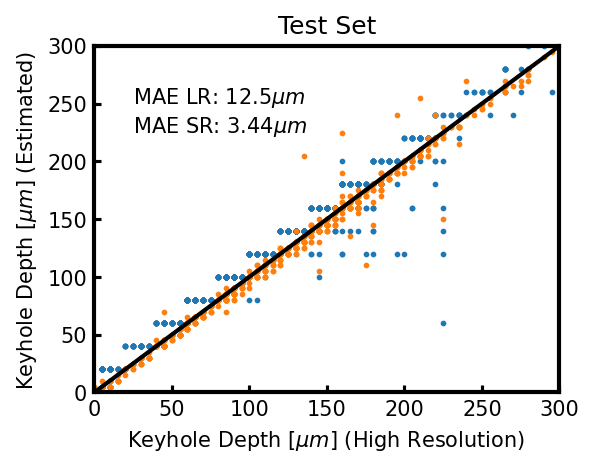

In [15]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(max_depth_gt, max_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(max_depth_gt, max_depth, s = 3.0, label = 'Super Resolution')
mae_input = mean_absolute_error(max_depth_gt, max_depth_input)
mae_depth = mean_absolute_error(max_depth_gt, max_depth)


# plt.plot(np.arange(300),np.arange(300)-2.27, 'k--', linewidth = 2.0)
# plt.plot(np.arange(300),np.arange(300)+2.27, 'k--', linewidth = 2.0)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Keyhole Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Keyhole Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
# legend(location = 'lower right')
    
plt.show()

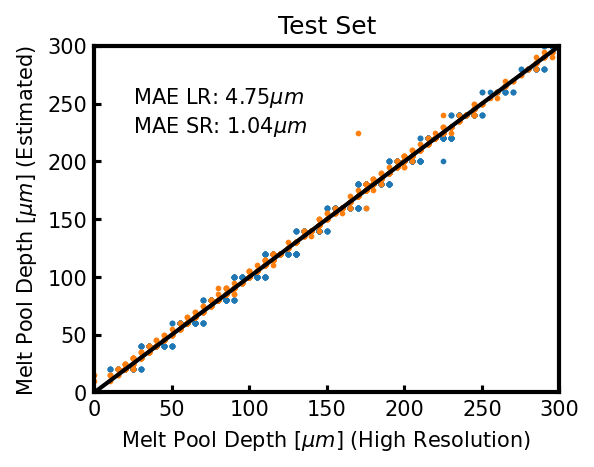

In [17]:
import sklearn
from sklearn.metrics import mean_absolute_error
plt.figure(figsize = [4,3], dpi = 150)
plt.plot(np.arange(300),np.arange(300), 'k-', linewidth = 2.0)
plt.scatter(kp_depth_gt, kp_depth_input, s = 3.0, label = 'Low Resolution')
plt.scatter(kp_depth_gt, kp_depth, s = 3.0, label = 'Super Resolution')
mae_input = mean_absolute_error(kp_depth_gt, kp_depth_input)
mae_depth = mean_absolute_error(kp_depth_gt, kp_depth)


# plt.plot(np.arange(300),np.arange(300)-2.27, 'k--', linewidth = 2.0)
# plt.plot(np.arange(300),np.arange(300)+2.27, 'k--', linewidth = 2.0)

plt.xlim(0,300)
plt.ylim(0,300)
frame_tick()
plt.xlabel(r'Melt Pool Depth [$\mu m]$ (High Resolution) ')
plt.ylabel(r'Melt Pool Depth [$\mu m]$ (Estimated) ')
plt.title('Test Set')
plt.text(25, 250,r'MAE LR: {:.03}$\mu m$'.format(mae_input) )
plt.text(25, 225,r'MAE SR: {:.03}$\mu m$'.format(mae_depth) )
# legend(location = 'lower right')
    
plt.show()

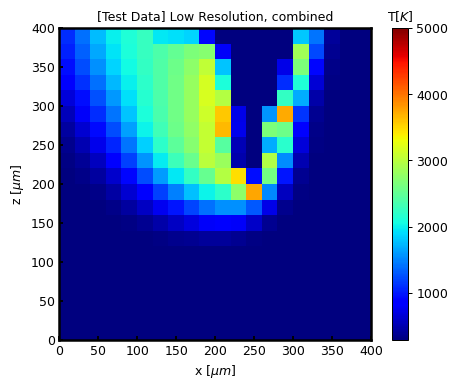

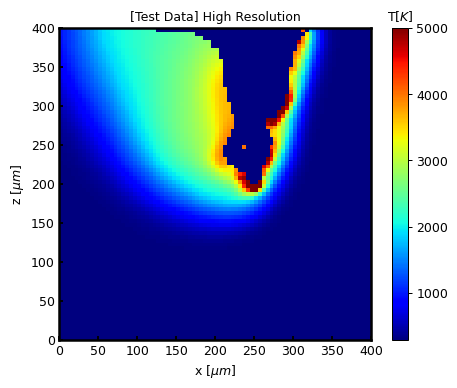

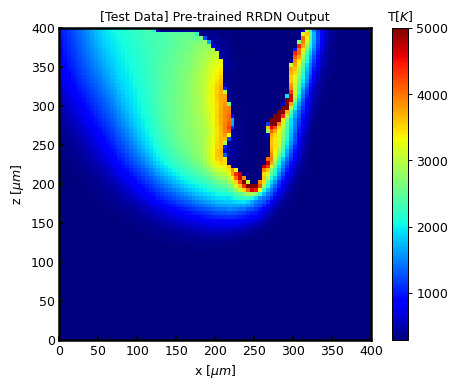

In [10]:
def plot_images_pretrained(split = 'train'):
    if split == 'train':
        img, target, result = predict(dataloader)
    elif split == 'test': 
        img, target, result = predict(dev_dataloader)
    
    std_lrs = train_dataset.std_lr
    mean_lrs = train_dataset.mean_lr
    lr_data =  img[:,0].cpu().detach().numpy()
    input_data = img[:,0].cpu().detach().numpy()
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 5000
    method = 'combined'
    true_lrs = input_data*std_lr + mean_lr

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow((true_lrs[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Low Resolution, {}'.format('Test', method), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((target[0]*train_dataset.std_hr + train_dataset.mean_hr).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] High Resolution'.format('Test'), fontsize = 10)
    plt.show()

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((result[0]*train_dataset.std_hr + train_dataset.mean_hr).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Pre-trained RRDN Output'.format('Test'), fontsize = 10)
    plt.show()

plot_images_pretrained(split = 'test')



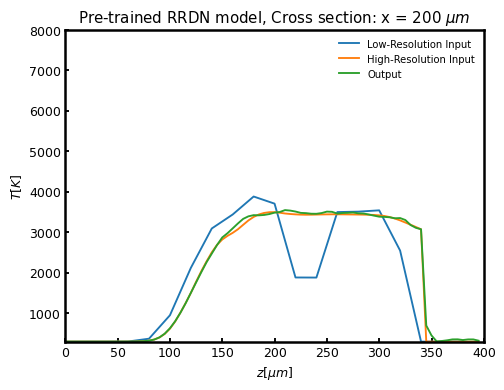

In [93]:
def plot_temp_lines_lrenc(split):
    if split == 'train':
        img, target, result = predict(dataloader)
    elif split == 'test': 
        img, target, result = predict(dev_dataloader)

    std_lrs = train_dataset.std_lr
    mean_lrs = train_dataset.mean_lr
    lr_data =  img[:,0].cpu().detach().numpy()
    input_data = img[:,0].cpu().detach().numpy()
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'lanczos'

    generated_hr = result*train_dataset.std_hr + train_dataset.mean_hr
    hr = target[:,0]*train_dataset.std_hr + train_dataset.mean_hr
    
    true_lrs = input_data*std_lrs + mean_lrs

    # dpi = 150
    # scaling_factor = 1.5
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.title(r'Pre-trained RRDN model, Cross section: x = 200 $\mu m$')
    plt.plot(80*5*(np.arange(true_lrs.shape[2])/true_lrs.shape[2]),true_lrs[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),hr[0][40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),generated_hr[0][40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()
# max_temp = 5000
# min_temp = 293
# dpi = 90
# scaling_factor = 1.5
# method = 'Lanczos'
plot_temp_lines_lrenc(split = 'train')

In [3]:
parent_directory = '/home/oogoke/SRdataset/epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
epoch = 148
data_1 = np.load(os.path.join(parent_directory, 'all_data-{}.npz').format(epoch))


In [19]:
from mobilenet_model import MobileNetv2_SISR, test_predictions, train_epoch, dev_epoch

device = 'cuda'
mobilenet = MobileNetv2_SISR()

mobilenet.to(device)
results_dir = '/home/oogoke/runs/clean/lanczos/mobilenet/2022_11_27_22_55_08'
mobilenetoptimizer = torch.optim.Adam(mobilenet.parameters(), lr=learning_rate,weight_decay = 0)
mobilenet_fname = os.path.join(results_dir, 'model_final.pth')
mobilenet_checkpoint = torch.load(mobilenet_fname)
mobilenet.load_state_dict(mobilenet_checkpoint['model_state_dict'])
mobilenetoptimizer.load_state_dict(mobilenet_checkpoint['optimizer_state_dict'])
# epoch = lrenc_checkpoint['epoch']
# loss = lrenc_checkpoint['loss']
mobilenet.eval()
import torch.nn.functional as F

In [20]:
for batch_num, (res, hr, true_lr, upscaled_lr) in tqdm(enumerate(data_loader), total=len(data_loader), ascii=True):

    # if np.random.random() > 0.5:
    #     #flip both img and target

    #     img = torch.flip(img, dims = [2])#[0][0]#torch.flip(img, dims =0)
    #     target =torch.flip(target, dims = [2])#[0][0]  #torch.flip(target, dims =0)
    
    img = upscaled_lr.view(upscaled_lr.shape[0], 1, upscaled_lr.shape[1], upscaled_lr.shape[2])
    target = hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2])
    img = img.to(device)
    target = target.to(device)
    
    output = mobilenet(img)
    new_out = output#*(8000-293) + 293
    break

  0%|          | 0/761 [00:00<?, ?it/s]


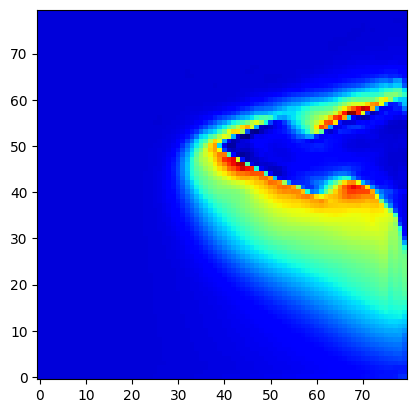

In [26]:
plt.imshow(new_out.detach().cpu().numpy()[0][0]*std+mean, cmap = 'jet', origin = 'lower')

In [11]:
std_resid = data_1['std_resid']
mean_resid = data_1['mean_resid']
std_lrs = data_1['std_lrs']
mean_lrs = data_1['mean_lrs']
sampled_data = data_1['sampled']
lr_data = data_1['upscaled_lr']
input_data = data_1['true_lr']
residuals = sampled_data[:,0]*std_resid + mean_resid

true_residual = data_1['res']*std_resid + mean_resid
true_lrs = input_data*std_lrs + mean_lrs
hr = data_1['hr']
generated_hr = lr_data + residuals

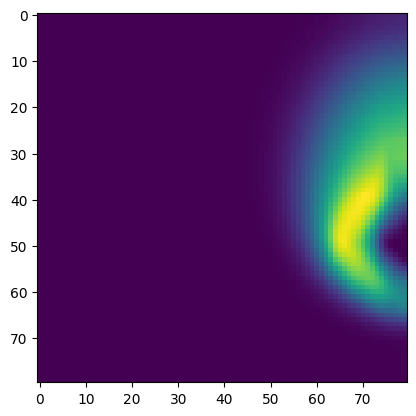

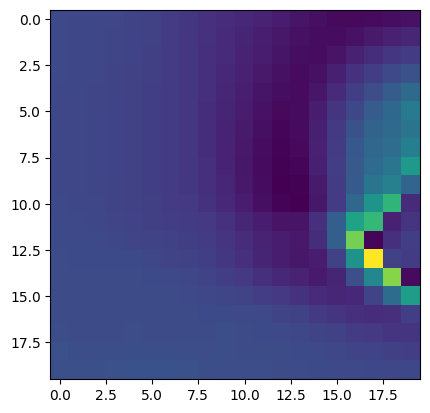

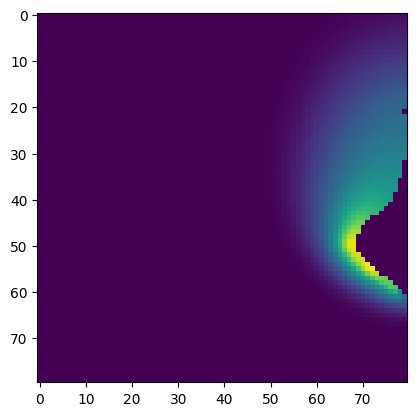

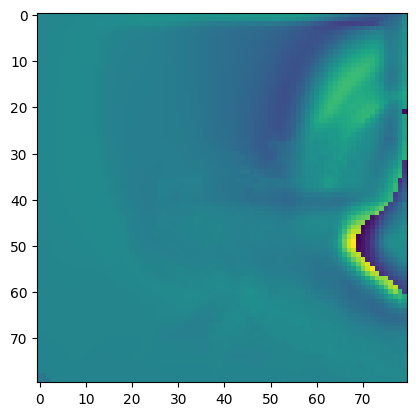

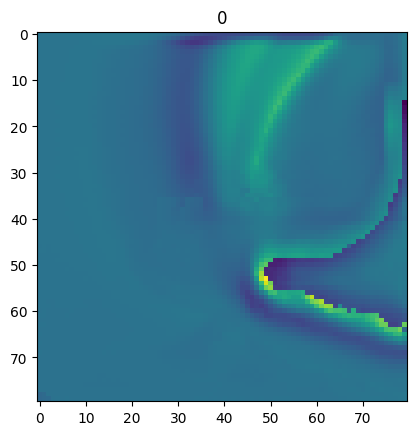

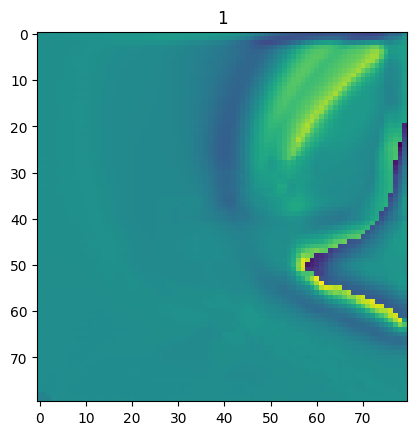

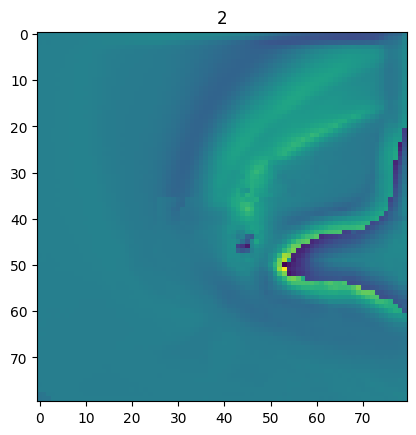

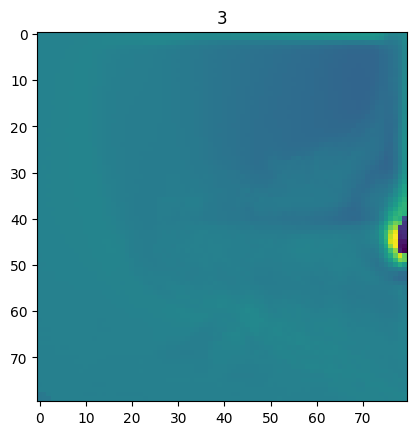

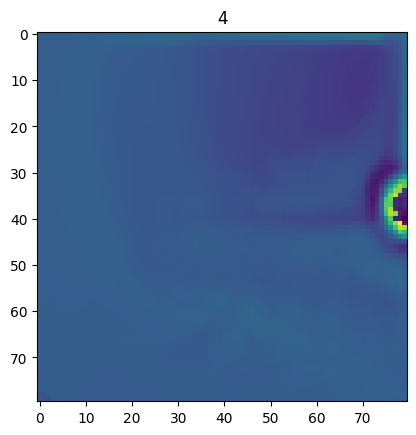

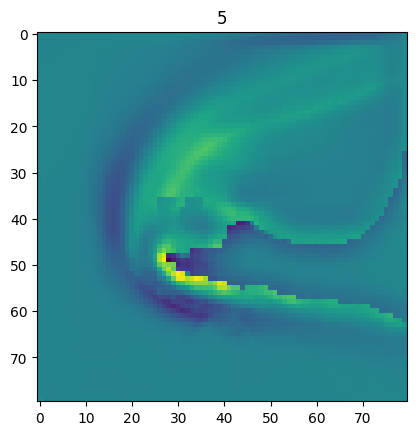

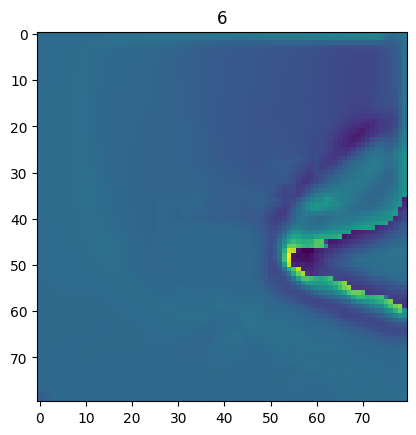

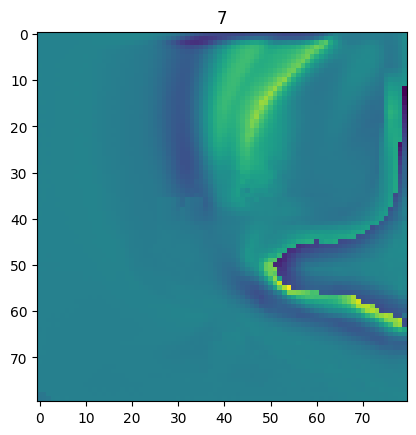

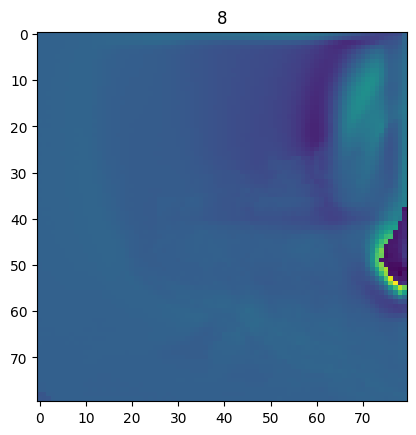

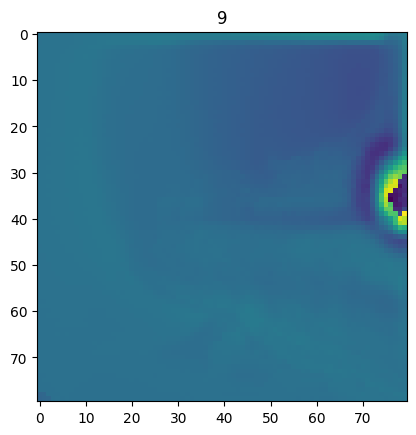

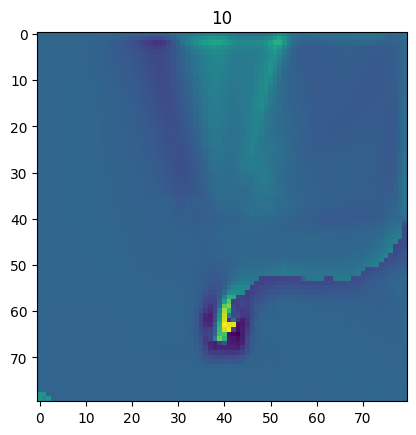

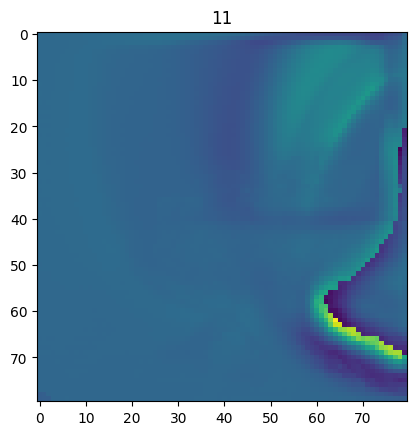

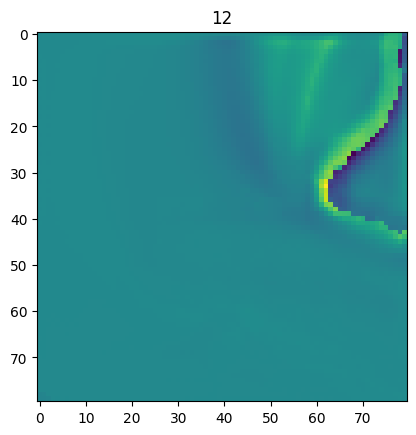

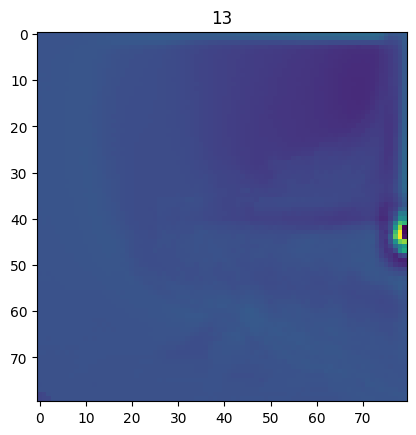

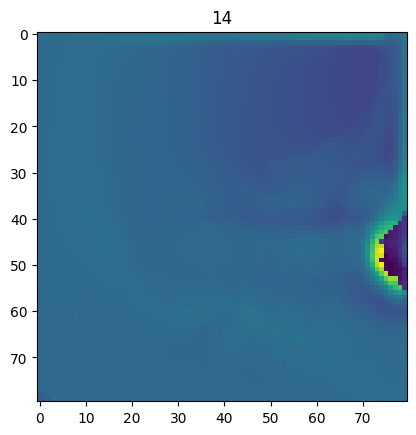

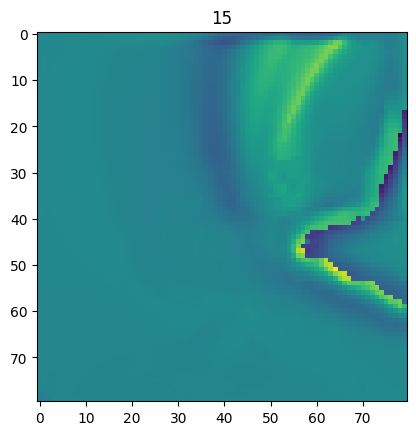

In [6]:
plt.imshow(data_1['upscaled_lr'][0])
plt.show()
plt.imshow(data_1['true_lr'][0])
plt.show()
plt.imshow(data_1['hr'][0])
plt.show()
plt.imshow(data_1['res'][0])
plt.show()
for i in range(16):
    plt.title(i)
    plt.imshow(data_1['sampled'][i,0])
    plt.show()

In [12]:
def plot_temp_images_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):
# max_temp = 5000
# min_temp = 293
# dpi = 90
# scaling_factor = 1.5
# method = 'Lanczos'

    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow((true_lrs[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Low Resolution, {} downscaling'.format('Train', method), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((hr[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] High Resolution'.format('Train'), fontsize = 10)
    plt.show()


    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((residuals[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, Sampled'.format('Train'), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((true_residual[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, GT'.format('Train'), fontsize = 10)
    plt.show()

In [13]:
def plot_temp_lines_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):

    std_resid = data_1['std_resid']
    mean_resid = data_1['mean_resid']
    std_lrs = data_1['std_lrs']
    mean_lrs = data_1['mean_lrs']
    sampled_data = data_1['sampled']
    lr_data = data_1['upscaled_lr']
    input_data = data_1['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data_1['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data_1['hr']
    generated_hr = lr_data + residuals
    # dpi = 150
    # scaling_factor = 1.5
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.title(r'SRDiff model, Cross section: x = 200 $\mu m$')
    plt.plot(80*5*(np.arange(true_lrs.shape[2])/true_lrs.shape[2]),true_lrs[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),hr[0][40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),generated_hr[0][40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()

In [94]:
def get_keyhole_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.max(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)

def get_mp_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.min(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)


In [15]:
def plot_srdiff_contours(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos', split = 'Train'):
    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    

    residuals = sampled_data[:,0]*std_resid + mean_resid
    generated_hr = lr_data + residuals
    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']
    profile = get_keyhole_profile(generated_hr)
    profile_gt = get_keyhole_profile(hr)
    profile_input = get_keyhole_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Keyhole Depth'.format('Train'), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')


    profile = get_mp_profile(generated_hr)
    profile_gt = get_mp_profile(hr)
    profile_input = get_mp_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Melt Pool Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')

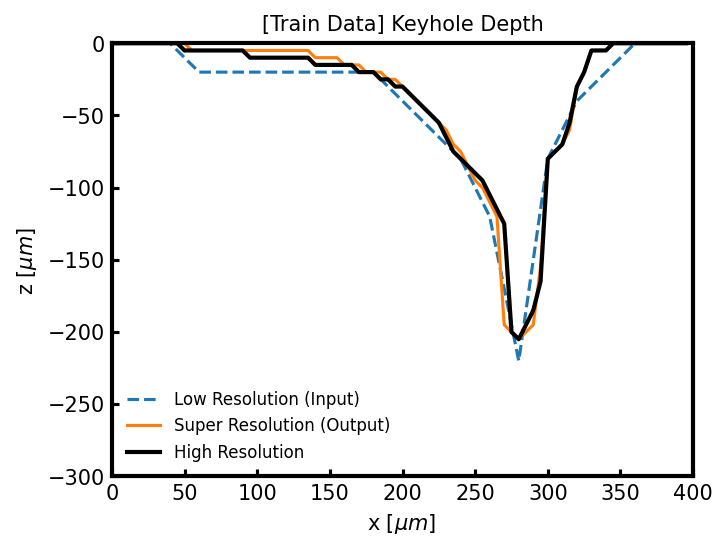

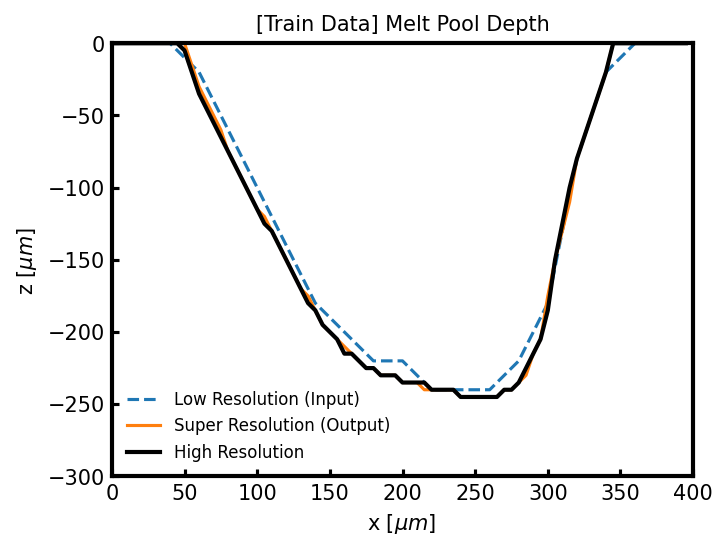

In [99]:
def plot_lrenc_contours(split = 'Train'):
    if split == 'Train':
        img, target, result = predict(dataloader)
    elif split == 'Test': 
        img, target, result = predict(dev_dataloader)

    std_lrs = train_dataset.std_lr
    mean_lrs = train_dataset.mean_lr
    lr_data =  img[:,0].cpu().detach().numpy()
    input_data = img[:,0].cpu().detach().numpy()
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 8000
    method = 'All'

    generated_hr = result*train_dataset.std_hr + train_dataset.mean_hr
    hr = target[:,0]*train_dataset.std_hr + train_dataset.mean_hr
    
    true_lrs = input_data*std_lr + mean_lr

    profile = get_keyhole_profile(generated_hr)
    profile_gt = get_keyhole_profile(hr)
    profile_input = get_keyhole_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    plt.xlim([0, 400])

    legend()
    plt.title('[{} Data] Keyhole Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')


    profile = get_mp_profile(generated_hr)
    profile_gt = get_mp_profile(hr)
    profile_input = get_mp_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    plt.xlim([0, 400])
    legend()
    plt.title('[{} Data] Melt Pool Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
plot_lrenc_contours(split ='Train')

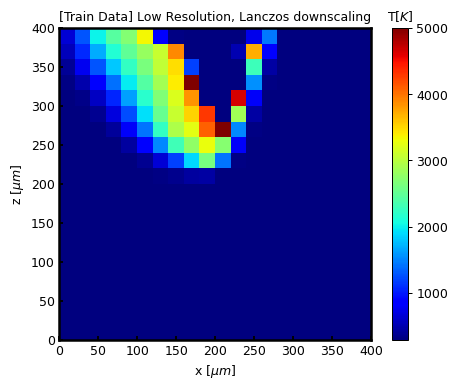

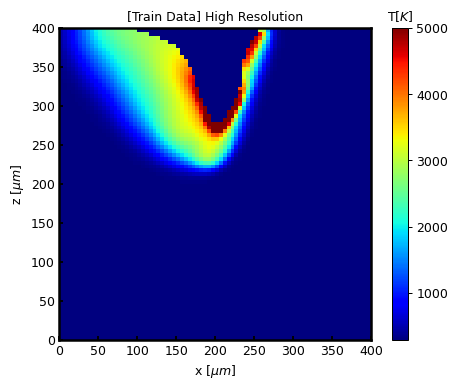

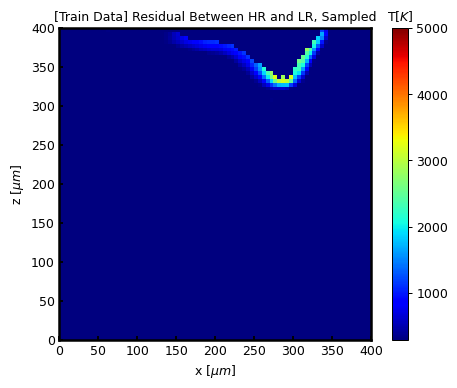

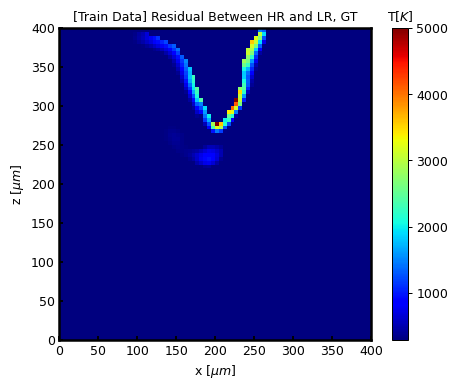

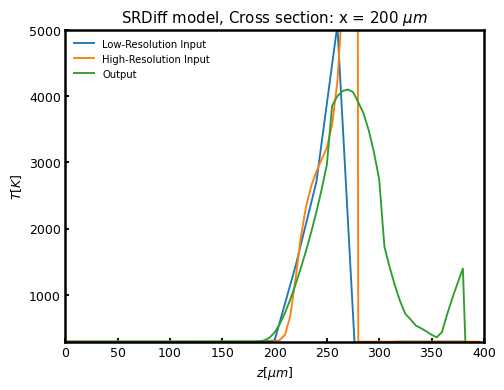

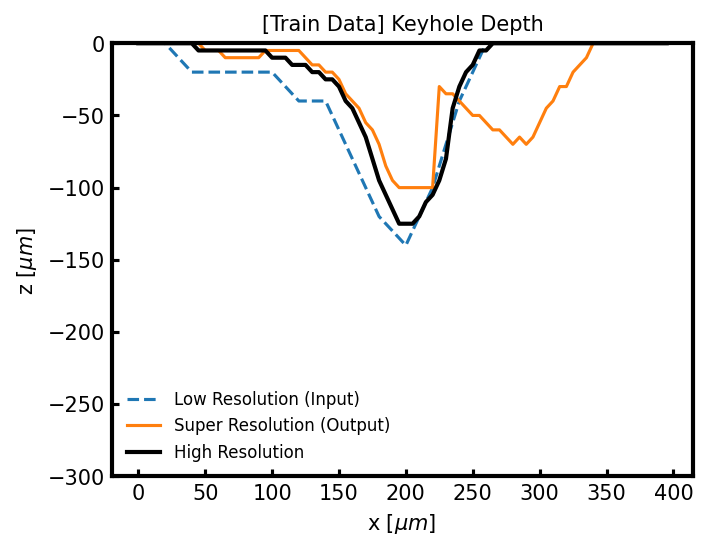

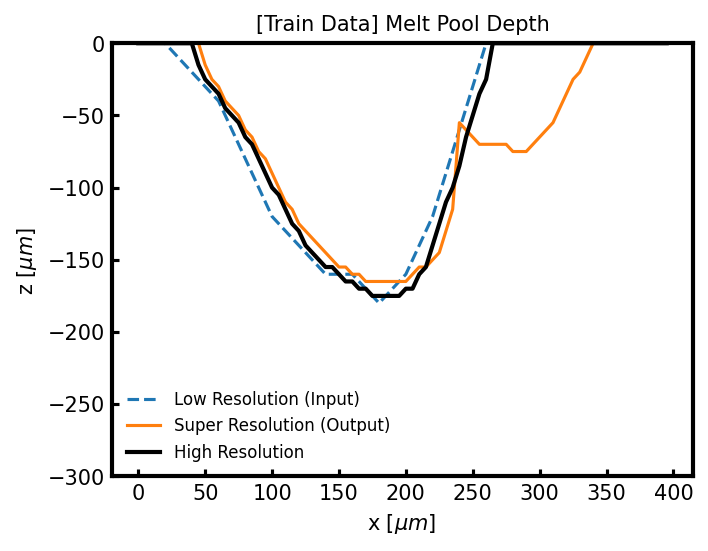

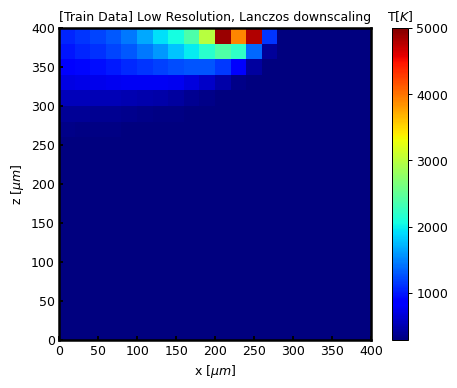

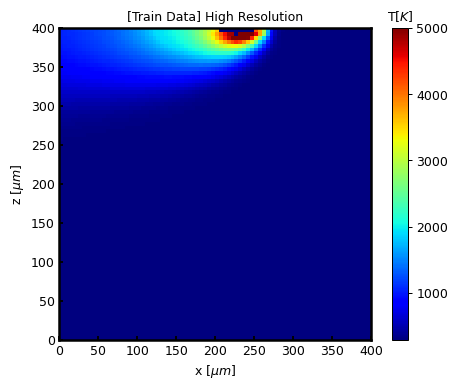

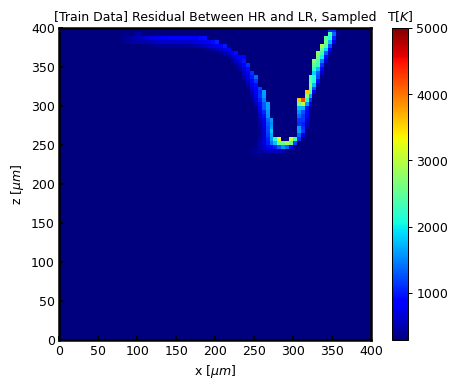

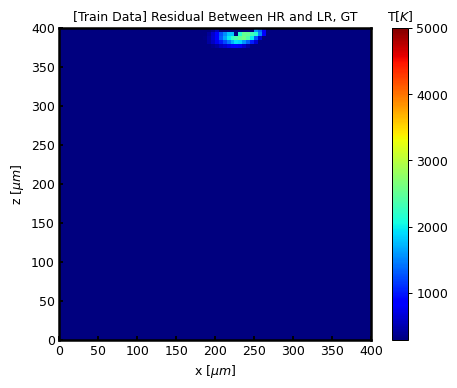

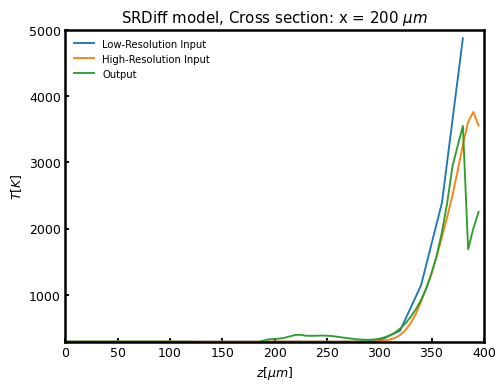

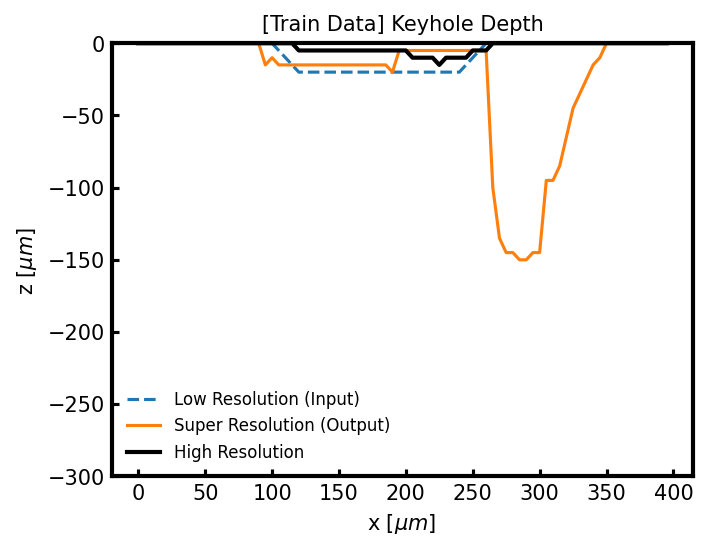

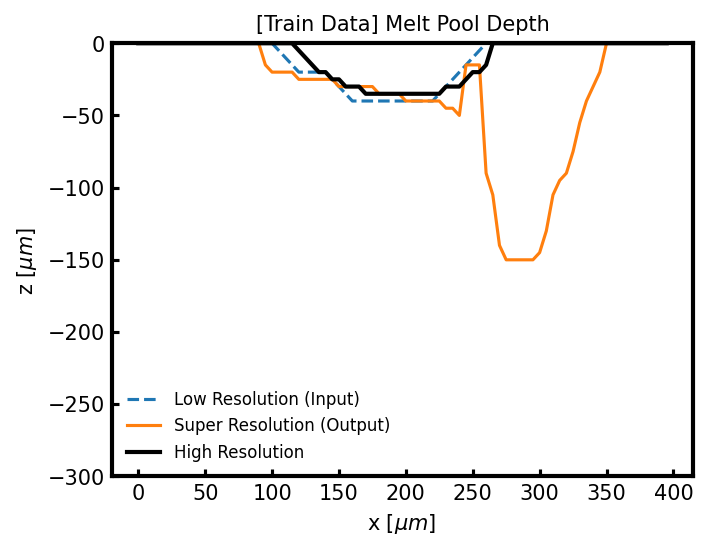

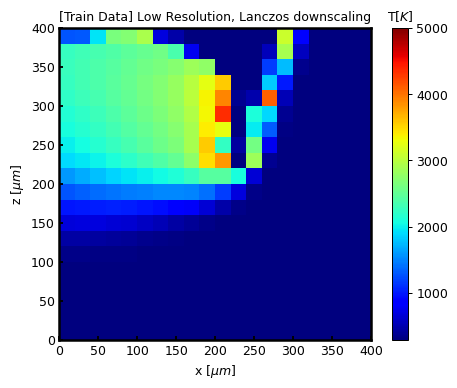

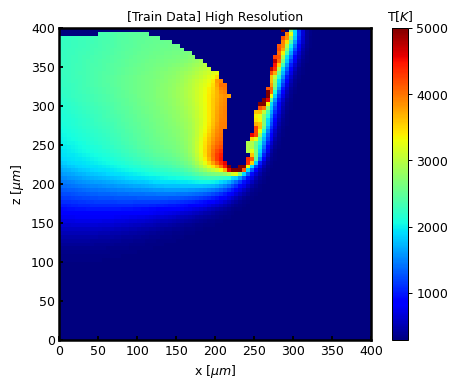

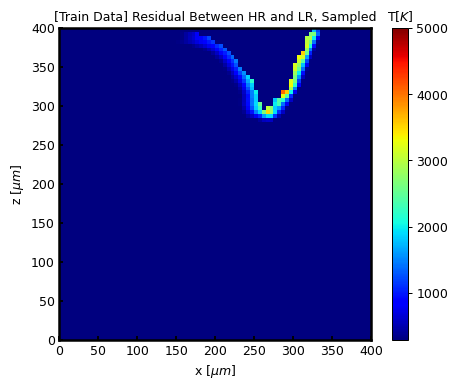

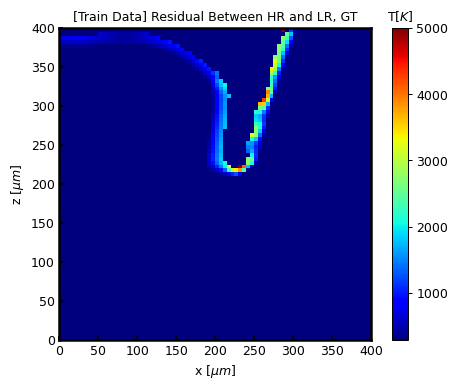

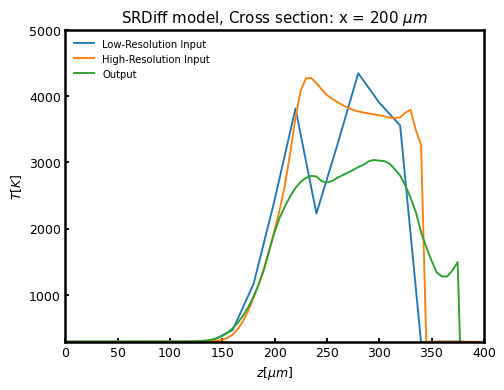

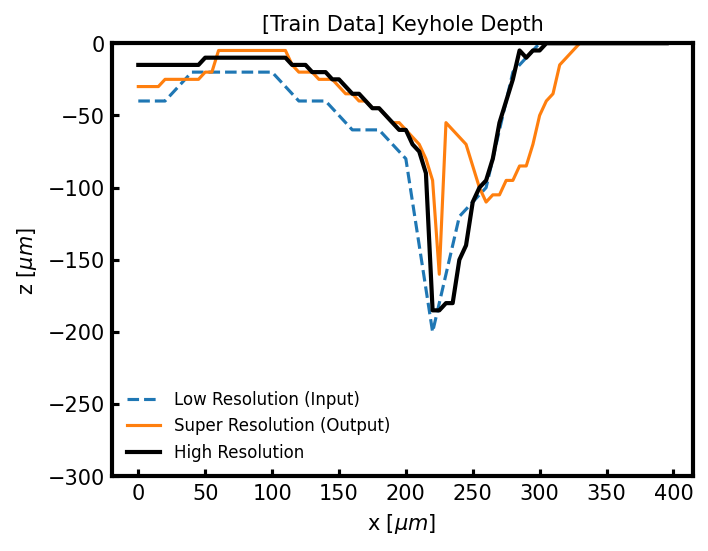

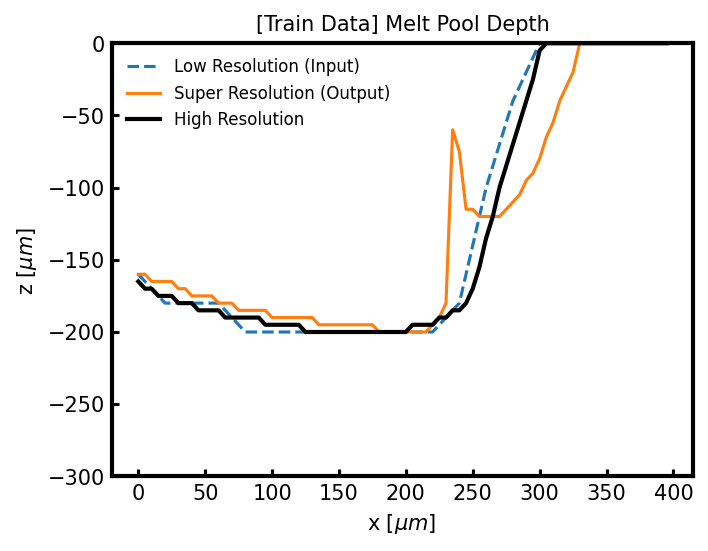

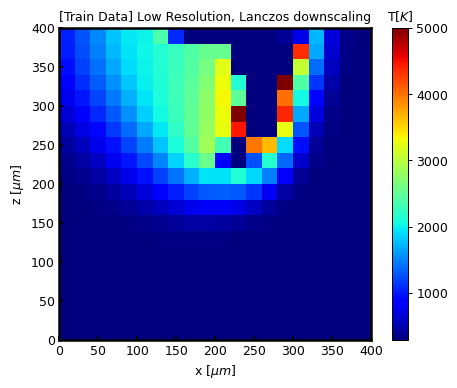

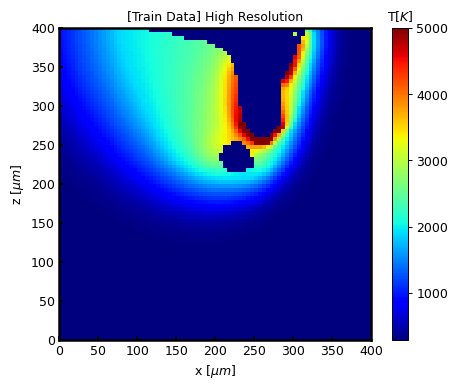

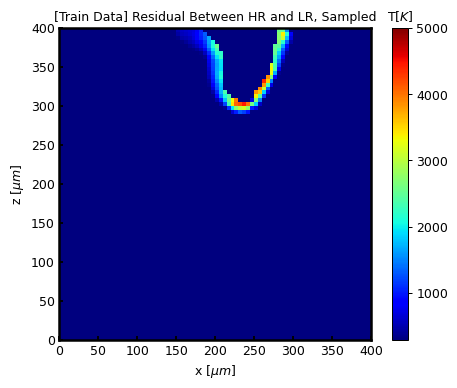

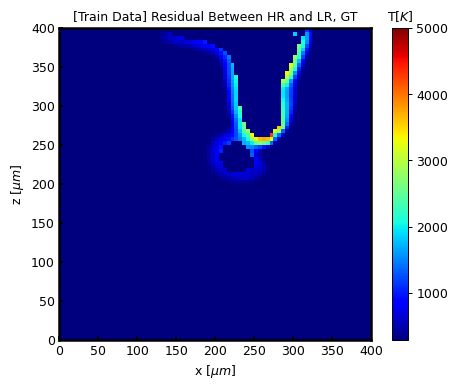

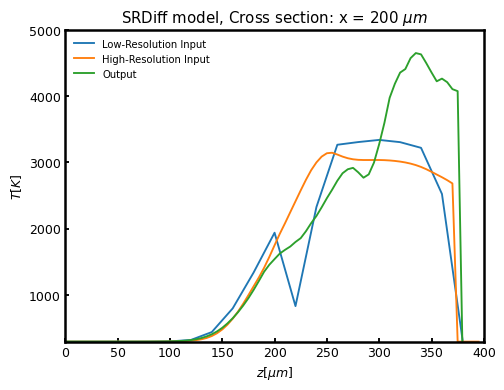

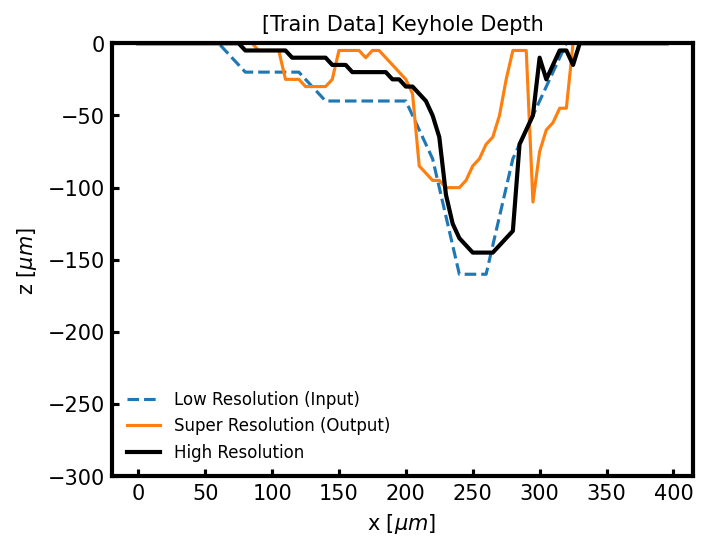

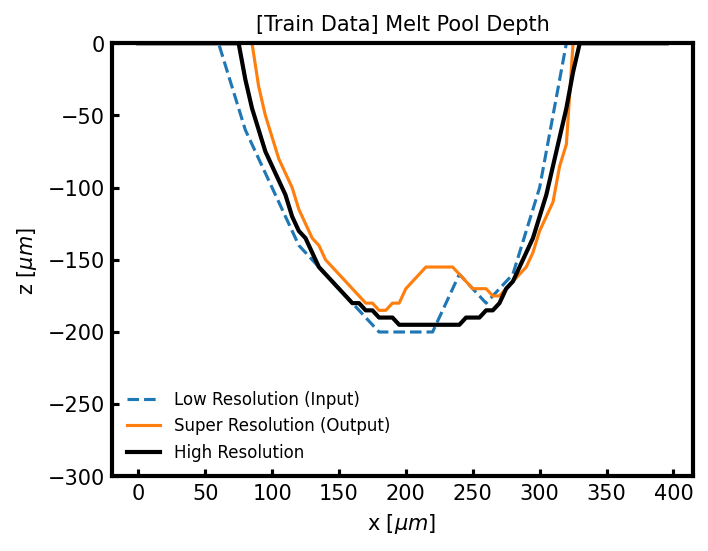

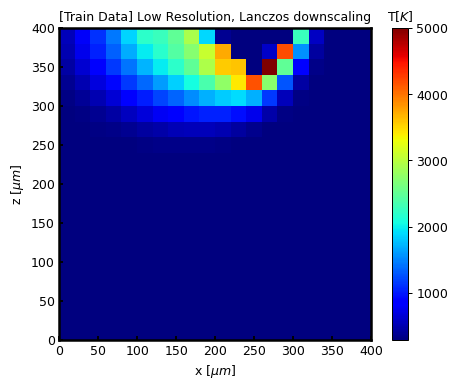

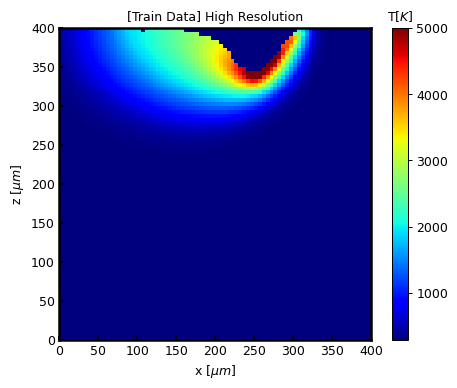

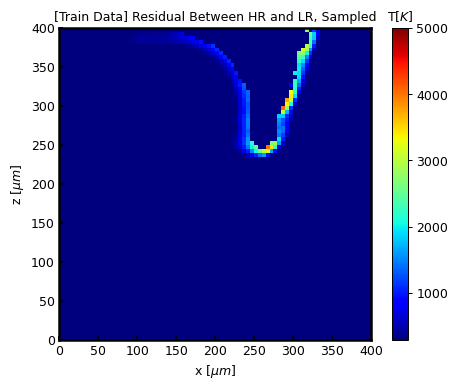

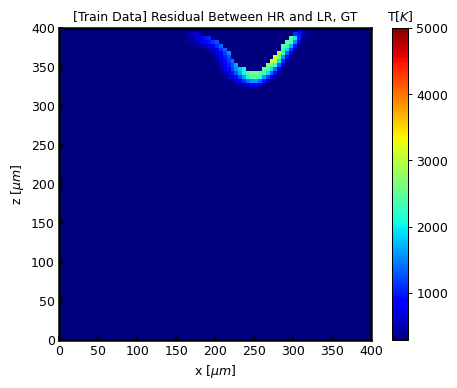

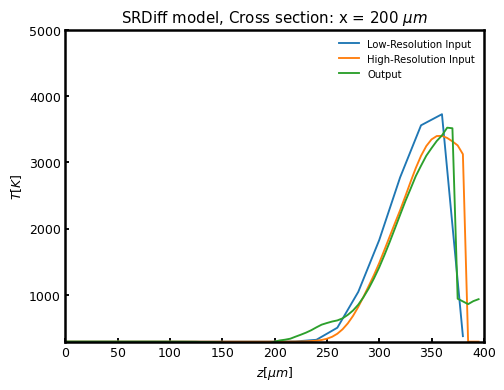

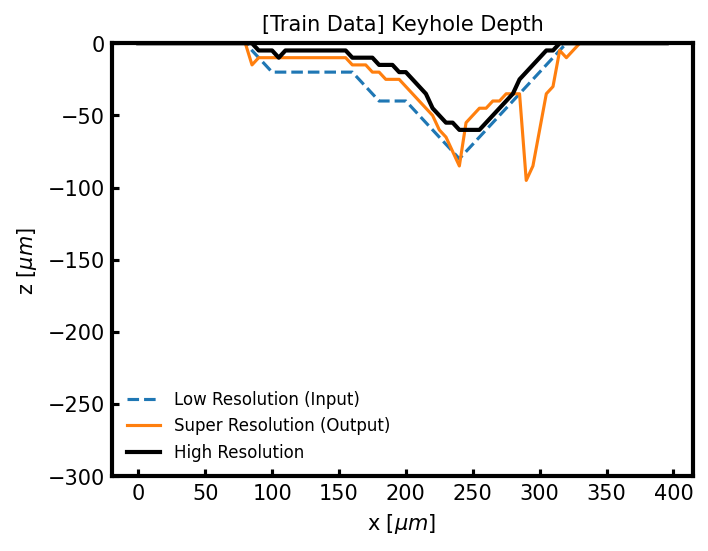

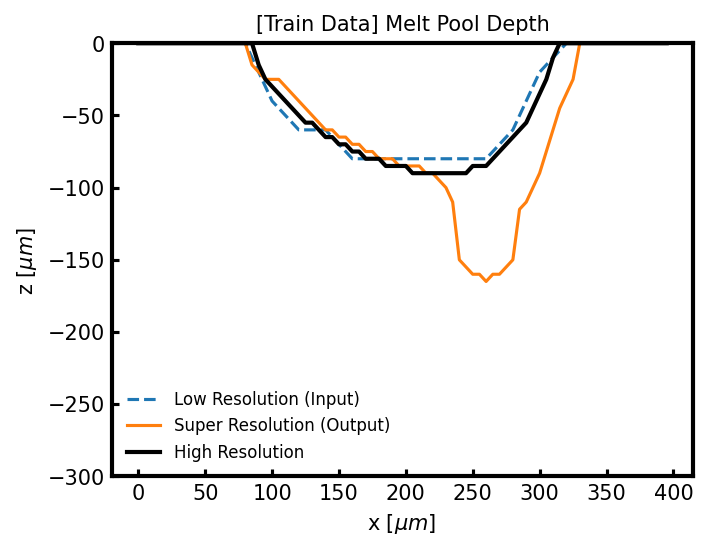

In [135]:
for epoch in range(140, 150, 2):
    parent_directory = '/home/oogoke/SRdataset/epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
    data_1 = np.load(os.path.join(parent_directory, 'all_data-{}.npz').format(epoch))
    plot_temp_images_srdiff(data_1)
    plot_temp_lines_srdiff(data_1)
    plot_srdiff_contours(data_1)



In [19]:
def PSNR(op, t, batch_size): 
    mse = np.sum((t - op) ** 2) 
    #print(mse.size())
    mse /= (batch_size*80*80)

    max_pixel = np.max(t)
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    #print(psnr.size())
    return psnr 
print('LR PSNR: ', PSNR(lr_data, hr, hr.shape[0]))
print('HR PSNR: ',PSNR(generated_hr, hr, hr.shape[0]))


LR PSNR:  49.80645208464533
HR PSNR:  49.518778607525974


In [30]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))



LR SSIM:  0.8817596485529187
SR SSIM:  0.35304429597642695
